# M6 — Notebook 00 · Setup, geometry & adjacency

**What M6 is.** A *geomatics-only* model: predictors are spatial / remotely-sensed landscape
layers **only**. No recent case counts (that is M1). No ERA5/CHIRPS reanalysis climate lags
(that is M2). M6 is the spatial-layer analogue of M2's "weather only".

**What M6 is for.** It is an **exploratory sensitivity comparator, not a headline model**.
The question it answers: *does a purely spatial/landscape model carry any standalone
early-warning signal — and does it beat season (M0) or climate-only (M2) on net benefit?*
The expected, honest answer is **no or marginal**, and that null is a legitimate result.

**Non-negotiable comparability rule** (`docs/M6.md` §0): M6 is scored on the **identical test
rows** as M1/M2/M5, with the **same evaluation code, split, threshold and bootstrap seed**.
If M6 cannot score the same rows — **stop**.

---

### What this notebook does

Establishes the spatial frame everything else is built on, and *verifies* it rather than
trusting it:

1. Load the 26-RDHS geometry and inspect it
2. Validate: unit count, geometry validity, duplicate IDs, name crosswalk
3. Choose a genuinely **equal-area** CRS and justify it
4. Check area conservation between projections
5. Build the queen-contiguity adjacency graph and check it against the known-good
   **26 nodes / 60 edges, connected, no cross-sea edges**
6. Checksum the inputs so downstream notebooks can assert provenance

Nothing here needs the outcome table or any staged raster — it runs today, offline.

## 1 · Environment

Print versions rather than assume them. Every number produced downstream is conditional on
this stack, and the repo's reproducibility gate expects the environment to be recorded.

In [1]:
import sys, platform, hashlib, json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import pyproj
import matplotlib
import matplotlib.pyplot as plt

print("python     ", sys.version.split()[0], "|", platform.platform())
for m in (np, pd, gpd, shapely, pyproj, matplotlib):
    print(f"{m.__name__:<11}", m.__version__)

python      3.12.13 | macOS-15.3.1-arm64-arm-64bit
numpy       2.5.1
pandas      3.0.5
geopandas   1.1.4
shapely     2.1.2
pyproj      3.7.2
matplotlib  3.11.1


## 2 · Configuration

One cell, all the constants. `SEED` matches the frozen analysis (`seed 20260612`) so anything
stochastic here lines up with the published pipeline.

In [2]:
SEED = 20260612          # matches the frozen analysis bootstrap seed
rng = np.random.default_rng(SEED)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"
QUAR = REPO / "data_quarantine" / "m6_geomatics"     # gitignored; never commit features
QUAR.mkdir(parents=True, exist_ok=True)

N_UNITS_EXPECTED = 26     # 26 RDHS analytic units
N_EDGES_EXPECTED = 60     # queen contiguity, per docs/maup_sensitivity_and_spatial_cv_plan.md §2

print("repo      ", REPO)
print("geometry  ", GEOM, "| exists:", GEOM.exists())
print("quarantine", QUAR)
print("seed      ", SEED)

repo       /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration
geometry   /Users/mpcr/aj/Dengue/dengue_map_workpack/geometry/rdhs_26_v1.gpkg | exists: True
quarantine /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration/data_quarantine/m6_geomatics
seed       20260612


## 3 · Load the geometry

`rdhs_26_v1.gpkg` is the frozen 26-unit frame: 24 districts map one-to-one, and Ampara is
split into **Ampara + Kalmunai** along divisional-secretariat boundaries. That split is why
the count is 26 and not 25 — it is the single most common source of confusion in this project.

In [3]:
rdhs = gpd.read_file(GEOM)

print("shape :", rdhs.shape)
print("CRS   :", rdhs.crs)
print("dtypes:")
print(rdhs.dtypes.to_string())

shape : (26, 8)
CRS   : EPSG:4326
dtypes:
rdhs_id                 str
rdhs_name               str
geometry_id             str
parent_district         str
province                str
build_rule              str
n_ds                float64
geometry           geometry


In [4]:
rdhs.drop(columns="geometry").head(26)

,rdhs_id,rdhs_name,geometry_id,parent_district,province,build_rule,n_ds
0,RDHS_01,Colombo,LK11,Colombo,Western,district_1to1,NaN
1,RDHS_02,Gampaha,LK12,Gampaha,Western,district_1to1,NaN
2,RDHS_03,Kalutara,LK13,Kalutara,Western,district_1to1,NaN
3,RDHS_04,Kandy,LK21,Kandy,Central,district_1to1,NaN
4,RDHS_05,Matale,LK22,Matale,Central,district_1to1,NaN
5,RDHS_06,Nuwara Eliya,LK23,Nuwara Eliya,Central,district_1to1,NaN
6,RDHS_07,Galle,LK31,Galle,Southern,district_1to1,NaN
7,RDHS_08,Matara,LK32,Matara,Southern,district_1to1,NaN
8,RDHS_09,Hambantota,LK33,Hambantota,Southern,district_1to1,NaN
9,RDHS_10,Jaffna,LK41,Jaffna,Northern,district_1to1,NaN


## 4 · Validate before trusting

Four assertions. Each one has bitten a real geospatial pipeline before: wrong unit count from a
bad dissolve, invalid rings from a topology error, duplicate IDs from a botched join, and
null geometries that silently drop rows in a zonal stat.

In [5]:
checks = {}

checks["unit count == 26"]      = len(rdhs) == N_UNITS_EXPECTED
checks["all geometries valid"]  = bool(rdhs.geometry.is_valid.all())
checks["no null geometries"]    = bool(rdhs.geometry.notna().all())
checks["rdhs_id unique"]        = rdhs["rdhs_id"].is_unique
checks["rdhs_name unique"]      = rdhs["rdhs_name"].is_unique
checks["no empty geometries"]   = not bool(rdhs.geometry.is_empty.any())

for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")

assert all(checks.values()), "geometry validation failed — stop and inspect before continuing"
print("\nall geometry checks passed")

  PASS  unit count == 26
  PASS  all geometries valid
  PASS  no null geometries
  PASS  rdhs_id unique
  PASS  rdhs_name unique
  PASS  no empty geometries

all geometry checks passed


Confirm the Ampara/Kalmunai split is actually present — the defining feature of this frame.

In [6]:
split_rows = rdhs[rdhs["parent_district"].str.contains("Ampara", case=False, na=False)]
print("units whose parent district is Ampara:", len(split_rows))
print(split_rows[["rdhs_id", "rdhs_name", "parent_district", "build_rule", "n_ds"]].to_string(index=False))

units whose parent district is Ampara: 2
rdhs_id rdhs_name parent_district     build_rule  n_ds
RDHS_25  Kalmunai          Ampara dissolve_12_DS  12.0
RDHS_26    Ampara          Ampara  dissolve_7_DS   7.0


## 5 · Choosing a CRS — and a correction to the plan

`maup_sensitivity_and_spatial_cv_plan.md` §5 says *"all weighting in equal-area projection"* and
suggests **SLD99 / Sri Lanka Grid or UTM 44N**.

**Both of those are transverse Mercator — conformal, not equal-area.** They preserve angles and
distort area. The manuscript is already careful about this: the Figure 1 caption explicitly
labels EPSG:32644 as *"transverse Mercator, used for display, not an equal-area projection."*

For *display* that is fine. For **area-weighted or population-weighted aggregation it is not** —
that is precisely the operation the plan wants protected. So we define a true
**Lambert Azimuthal Equal-Area** projection centred on Sri Lanka and use it for every
area-bearing computation.

We keep three CRS with distinct jobs, and never mix them up:

| CRS | Use | Why |
|---|---|---|
| `EPSG:4326` | storage, distribution | what the file ships in; degrees — **never** compute area here |
| `EPSG:32644` (UTM 44N) | display / figure parity | matches manuscript Fig 1 panel A |
| custom **LAEA** | all areas, weights, buffers | genuinely equal-area |

In [7]:
CRS_STORAGE = "EPSG:4326"
CRS_DISPLAY = "EPSG:32644"          # UTM 44N — matches manuscript Fig 1A (conformal, display only)

# Lambert Azimuthal Equal-Area centred on the island's centroid
c = rdhs.to_crs(CRS_DISPLAY).union_all().centroid
c_ll = gpd.GeoSeries([c], crs=CRS_DISPLAY).to_crs(CRS_STORAGE).iloc[0]
CRS_EQUAL_AREA = (
    f"+proj=laea +lat_0={c_ll.y:.4f} +lon_0={c_ll.x:.4f} "
    "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

print(f"island centroid : {c_ll.y:.4f} N, {c_ll.x:.4f} E")
print("equal-area CRS  :", CRS_EQUAL_AREA)

rdhs_ea = rdhs.to_crs(CRS_EQUAL_AREA)
print("\nreprojected:", rdhs_ea.crs.name if rdhs_ea.crs.name else "custom LAEA")

island centroid : 7.6221 N, 80.6987 E
equal-area CRS  : +proj=laea +lat_0=7.6221 +lon_0=80.6987 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs

reprojected: unknown


### Does the projection choice actually matter here?

Rather than assert it, measure it. Compute each unit's area under the conformal projection and
under the equal-area projection, and look at the disagreement. If it were negligible the plan's
wording would be harmless — let's see.

In [8]:
area_utm  = rdhs.to_crs(CRS_DISPLAY).area / 1e6      # km^2
area_laea = rdhs_ea.area / 1e6                        # km^2

cmp = pd.DataFrame({
    "rdhs_name": rdhs["rdhs_name"],
    "area_utm_km2":  area_utm.values,
    "area_laea_km2": area_laea.values,
})
cmp["diff_km2"] = cmp["area_utm_km2"] - cmp["area_laea_km2"]
cmp["pct_error"] = 100 * cmp["diff_km2"] / cmp["area_laea_km2"]

print(f"total area  UTM 44N : {cmp['area_utm_km2'].sum():>10,.1f} km2")
print(f"total area  LAEA    : {cmp['area_laea_km2'].sum():>10,.1f} km2")
print(f"published Sri Lanka : {65610:>10,} km2   (land area, for reference)")
print()
print(f"per-unit area error : {cmp['pct_error'].min():+.3f}% to {cmp['pct_error'].max():+.3f}%")
cmp.reindex(cmp["pct_error"].abs().sort_values(ascending=False).index).head(8)

total area  UTM 44N :   65,995.0 km2
total area  LAEA    :   66,040.8 km2
published Sri Lanka :     65,610 km2   (land area, for reference)

per-unit area error : -0.080% to -0.044%


,rdhs_name,area_utm_km2,area_laea_km2,diff_km2,pct_error
20,Badulla,2869.669116,2871.955927,-2.286811,-0.079626
19,Polonnaruwa,3466.964349,3469.716398,-2.752049,-0.079316
15,Trincomalee,2689.973966,2692.106232,-2.132266,-0.079204
4,Matale,2057.154547,2058.748384,-1.593837,-0.077418
8,Hambantota,2623.036165,2625.064152,-2.027987,-0.077255
5,Nuwara Eliya,1743.471559,1744.814837,-1.343278,-0.076987
3,Kandy,1926.206595,1927.685470,-1.478875,-0.076718
21,Moneragala,5753.605362,5757.988873,-4.383511,-0.076129


## 6 · Look at it

Two panels: the frame as it will appear in figures, and the area-error field. The second is the
diagnostic — if the error had spatial structure aligned with population, an area-weighted
exposure built in the wrong CRS would bias systematically rather than randomly.

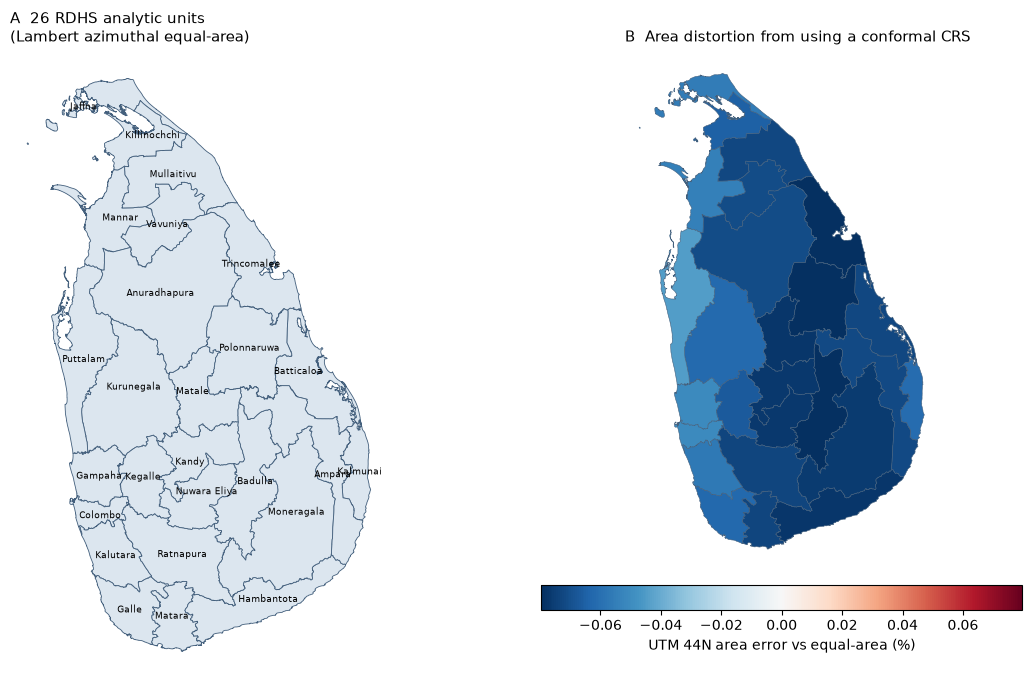

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))

ax = axes[0]
rdhs_ea.plot(ax=ax, facecolor="#dce6ef", edgecolor="#44607d", linewidth=0.6)
for _, r in rdhs_ea.iterrows():
    p = r.geometry.representative_point()
    ax.annotate(r["rdhs_name"], (p.x, p.y), ha="center", va="center", fontsize=6.5)
ax.set_title("A  26 RDHS analytic units\n(Lambert azimuthal equal-area)", loc="left", fontsize=11)
ax.set_axis_off()

ax = axes[1]
tmp = rdhs_ea.copy()
tmp["pct_error"] = cmp["pct_error"].values
vmax = tmp["pct_error"].abs().max()
tmp.plot(column="pct_error", ax=ax, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
         edgecolor="#44607d", linewidth=0.4, legend=True,
         legend_kwds={"label": "UTM 44N area error vs equal-area (%)",
                      "orientation": "horizontal", "shrink": 0.7, "pad": 0.02})
ax.set_title("B  Area distortion from using a conformal CRS", loc="left", fontsize=11)
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 7 · Adjacency graph

Queen contiguity — units sharing an edge *or* a corner are neighbours. This graph is the
backbone of everything spatial downstream: Moran's I, the buffered leave-one-out folds (WP4),
and any spatial-lag feature.

The plan records a known-good result: **26 nodes / 60 edges, connected, no cross-sea edges.**
That gives us something to verify against instead of accepting whatever we compute.

In [10]:
from libpysal.weights import Queen

W = Queen.from_dataframe(rdhs_ea, use_index=False)

n_nodes = W.n
n_edges = int(sum(len(v) for v in W.neighbors.values()) // 2)
islands = list(W.islands)

print(f"nodes           : {n_nodes}   (expected {N_UNITS_EXPECTED})")
print(f"edges           : {n_edges}   (expected {N_EDGES_EXPECTED})")
print(f"islands         : {islands if islands else 'none'}")
print(f"mean degree     : {np.mean([len(v) for v in W.neighbors.values()]):.2f}")
print(f"degree range    : {min(len(v) for v in W.neighbors.values())} to {max(len(v) for v in W.neighbors.values())}")

if n_edges != N_EDGES_EXPECTED:
    print(f"\n  NOTE edge count differs from the recorded {N_EDGES_EXPECTED} — "
          "reconcile against docs/rdhs_adjacency_graph_build_report.md before using for WP4 folds")
else:
    print(f"\n  matches the recorded adjacency build ({N_EDGES_EXPECTED} edges)")

nodes           : 26   (expected 26)
edges           : 60   (expected 60)
islands         : none
mean degree     : 4.62
degree range    : 2 to 9

  matches the recorded adjacency build (60 edges)


Connectivity matters: a disconnected graph would mean some unit can never share information with
the rest, which changes how buffered CV folds behave. Check it explicitly.

In [11]:
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

A = W.sparse
n_comp, labels = connected_components(A, directed=False)

print("connected components:", n_comp)
for i in range(n_comp):
    members = rdhs_ea.loc[labels == i, "rdhs_name"].tolist()
    print(f"  component {i}: {len(members)} units", "" if len(members) > 3 else members)

print("\nconnected:" , n_comp == 1)

connected components: 1
  component 0: 26 units 

connected: True


Plot the graph over the map. Eyeballing this is the cheapest way to catch a **cross-sea edge** —
two coastal units on opposite shores joined because their bounding boxes touched. That error is
invisible in a summary statistic and obvious in a picture.

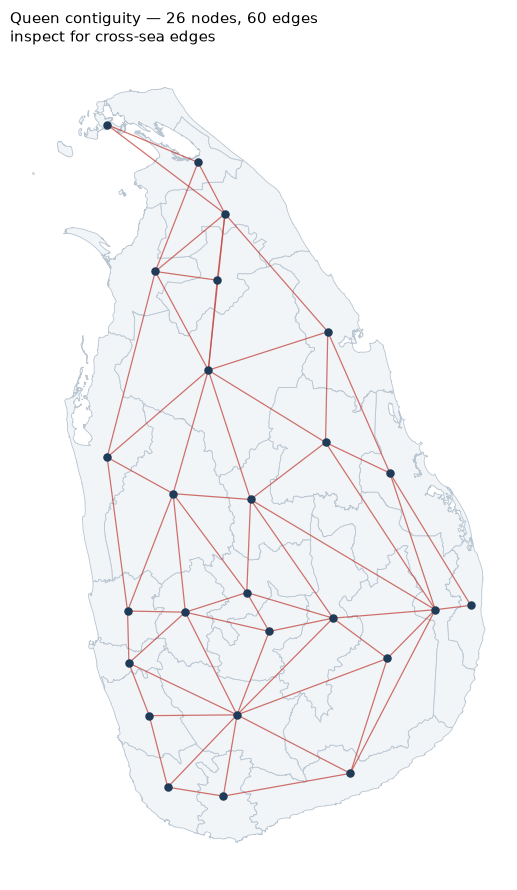

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 9))

rdhs_ea.plot(ax=ax, facecolor="#f2f5f8", edgecolor="#b9c6d2", linewidth=0.6)

pts = rdhs_ea.geometry.representative_point()
xy = np.c_[pts.x.values, pts.y.values]

for i, nbrs in W.neighbors.items():
    for j in nbrs:
        if i < j:
            ax.plot([xy[i, 0], xy[j, 0]], [xy[i, 1], xy[j, 1]],
                    color="#c1443c", linewidth=0.9, alpha=0.75, zorder=2)

ax.scatter(xy[:, 0], xy[:, 1], s=26, color="#1f3b57", zorder=3)
ax.set_title(f"Queen contiguity — {n_nodes} nodes, {n_edges} edges\n"
             "inspect for cross-sea edges", loc="left", fontsize=11)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 8 · Provenance

Checksum the geometry so every downstream notebook can assert it is standing on the same frame.
This is the same discipline the frozen pipeline uses (`input_sha256` in `_provenance.json`).

In [13]:
def sha256(path, n=16):
    h = hashlib.sha256(Path(path).read_bytes()).hexdigest()
    return h[:n]

provenance = {
    "notebook": "00_setup_and_geometry",
    "seed": SEED,
    "geometry_file": GEOM.name,
    "geometry_sha256_16": sha256(GEOM),
    "n_units": int(len(rdhs)),
    "n_edges_queen": n_edges,
    "connected": bool(n_comp == 1),
    "crs_storage": CRS_STORAGE,
    "crs_display": CRS_DISPLAY,
    "crs_equal_area": CRS_EQUAL_AREA,
    "total_area_km2_equalarea": round(float(area_laea.sum()), 1),
}

out = QUAR / "nb00_provenance.json"
out.write_text(json.dumps(provenance, indent=2))
print(json.dumps(provenance, indent=2))
print("\nwritten:", out)

{
  "notebook": "00_setup_and_geometry",
  "seed": 20260612,
  "geometry_file": "rdhs_26_v1.gpkg",
  "geometry_sha256_16": "9e5e2c0a541ecac1",
  "n_units": 26,
  "n_edges_queen": 60,
  "connected": true,
  "crs_storage": "EPSG:4326",
  "crs_display": "EPSG:32644",
  "crs_equal_area": "+proj=laea +lat_0=7.6221 +lon_0=80.6987 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs",
  "total_area_km2_equalarea": 66040.8
}

written: /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration/data_quarantine/m6_geomatics/nb00_provenance.json


## 9 · Recap

Every number this notebook established, in one table. Downstream notebooks assert against these.

In [14]:
recap = pd.DataFrame([
    ("analytic units",            len(rdhs),                      N_UNITS_EXPECTED),
    ("queen edges",               n_edges,                        N_EDGES_EXPECTED),
    ("connected components",      n_comp,                         1),
    ("invalid geometries",        int((~rdhs.geometry.is_valid).sum()), 0),
    ("duplicate rdhs_id",         int(rdhs['rdhs_id'].duplicated().sum()), 0),
], columns=["quantity", "observed", "expected"])
recap["ok"] = recap["observed"] == recap["expected"]

print(recap.to_string(index=False))
print()
print(f"total land area (equal-area) : {area_laea.sum():,.0f} km2")
print(f"max area error if a conformal CRS were used : {cmp['pct_error'].abs().max():.3f}%")
print()
print("ALL PASS" if recap["ok"].all() else "SOME CHECKS FAILED — do not proceed")

            quantity  observed  expected   ok
      analytic units        26        26 True
         queen edges        60        60 True
connected components         1         1 True
  invalid geometries         0         0 True
   duplicate rdhs_id         0         0 True

total land area (equal-area) : 66,041 km2
max area error if a conformal CRS were used : 0.080%

ALL PASS


---

### What is established

- A validated 26-unit spatial frame with the Ampara/Kalmunai split confirmed
- A genuinely equal-area CRS for all weighting — **correcting the plan's suggestion of
  SLD99/UTM 44N, both of which are conformal**
- A queen-contiguity graph checked against the recorded 26/60 build
- A provenance record downstream notebooks can assert against

### Next — `01_terrain_batchA.ipynb`

Batch A (DEM: elevation, slope, TWI, HAND) against this frame, from Copernicus GLO-30 on AWS
Open Data. **No Google Earth Engine anywhere in this workflow** — every source is an anonymous
public download, so a pinned granule id plus a local checksum reproduces the extraction exactly,
which a GEE collection that can be revised underneath you does not.

**Design note carried forward.** Those layers are *static per unit* — they produce one value per
district that never changes across weeks. A model built from static predictors alone yields a
**constant prediction per unit for every week**, so against a weekly elevated-activity label it
can only express *which* districts differ, never *when*. Its null would be structural rather
than empirical. The dynamic remotely-sensed layers in notebook 02 —
**MODIS LST and NDVI/EVI** — are what make M6 a real test. Nightlights and surface water were
expected to be dynamic too, but turned out not to be available that way (annual HREA, and a
cumulative water epoch), so they sit with the static layers in notebook 03.